In [157]:
#GRADIENT DESCENT: another way to find local minimum of f(x), find x0 where f'(x0) = 0

#As usual, to find local minimum or local maximum, we solve f'(x) = 0 equation to find x
#However, sometimes, it is impossible to solve that equation (too much data, too many dimensions,...)
#In that case, have to use Gradient Descent method to find x where f'(x) = 0

#The idea is:
#    If f'(x0) > 0, we have to decrease x to reach f'(x) = 0, meaning x_new = x0 - delta
#    If f'(x0) < 0, we have to increase x to reach f'(x) = 0, meaning x_new = x0 + delta
#In both cases, delta is always has the opposite sign of f'(x) (trai dau)
#Therefore, we can replace delta with -p.f'(x)
#    (p is learning rate)

#Formula: x_new = x0 - p.f'(x0)

#Keep repeat this formula to find x_new from x0, then find another x_new2 from the old x_new
#....repeat until f'(x0) = 0 ===> x_new = x0 (converge point)
#Use the x at converge point to calculate local minimum of f(x)

#Choose the p wisely
#If p is too large, we will be bouncing back and forth around converge point without reaching it
#If p is too small, it will take more loops to reach the converge point, hence take more time

print('')

In [159]:
#-------Gradient Descent for Linear Regression------------#
#In Linear regression, we often use Leas-square Method (LSM) to find the linear line y^ = ax + b
#which means that we have to find a and b satisfying sum((yi -y^i)**2) or sum((yi - a.xi -b )**2) to be the minimum
#let f(x) = sum((yi - a.xi -b )**2), the problem is now solving f'(x) = 0 
#but it's not possible to do that since the size of x and y are too much
# ==> Use Gradient Descent to find the local minimum satisfying LSM

In [161]:
"""=============================================================================
Ex5: Gradient Descent
    Cho dữ liệu chiều cao heights (heights_1.txt), weights (weights_1.txt)
        1) Tạo 2 numpy array heights và weights chứa 2 danh sách từ 2 tập tin trên.
        2) Chuyển inches --> mét (h * 0.0254), lbs --> kg (w * 0.453592)
        3) Trực quan hóa dữ liệu theo heights, weights
        4) x = heights đã chuyển theo định dạng chuẩn, y = weights
        5) Với phương trình: y = mx + b (weights = (m * heights) + b) 
            gọi hàm tính m, b: theta = gradient_descent_2(alpha, x, y, 1000)
        6) Từ m, b (m = theta[1], b = theta[0]), dự đoán weights_predict theo m, b
        7) Trực quan hóa dữ liệu
        8) Với chiều cao là 1.8, 1.9, 2.0 thì cân nặng lần lượt là bao nhiêu?   
============================================================================="""
print('-------------GRADIENT DESCENT: Method 1---------------------------------')

-------------GRADIENT DESCENT: Method 1---------------------------------


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from matplotlib.gridspec import GridSpec

In [165]:
print('\n=============================================================')
print('*** 1) Read data heights_1.txt and weights_1.txt into numpy array heights and weights***')
print('=============================================================')
print()

#-------read heights----------#
f1 = open('data_Buoi6/heights_1.txt','r')
heights = np.array(eval(f1.read()))
f1. close

print(f'Heights (inches) array: {heights}')

#-------read weights----------#
f2 = open('data_Buoi6/heights_1.txt','r')
weights = np.array(eval(f2.read()))
f2.close

print(f'Weights (pounds) array: {weights}')

print()


*** 1) Read data heights_1.txt and weights_1.txt into numpy array heights and weights***

Heights (inches) array: [74 74 72 ... 75 75 73]
Weights (pounds) array: [74 74 72 ... 75 75 73]



In [167]:
print('\n=============================================================')
print('*** 2) convert from inches --> meters (*0.0254) and from lbs ---> kg (*0.453592) ***')
print('=============================================================')
print()

heights = heights*0.0254
print(f'Heights (metters) array: {heights}')

weights = weights*0.453592
print(f'Weights (kilogr) array: {weights}')

print()


*** 2) convert from inches --> meters (*0.0254) and from lbs ---> kg (*0.453592) ***

Heights (metters) array: [1.8796 1.8796 1.8288 ... 1.905  1.905  1.8542]
Weights (kilogr) array: [33.565808 33.565808 32.658624 ... 34.0194   34.0194   33.112216]




*** 3) Visualize the data with heights and weights (use jointplot) ***



<Figure size 400x400 with 0 Axes>

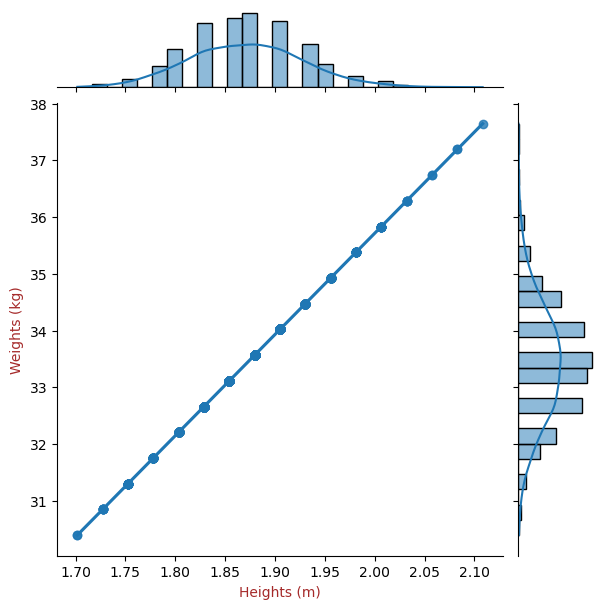

In [241]:
print('\n=============================================================')
print('*** 3) Visualize the data with heights and weights (use jointplot) ***')
print('=============================================================')
print()

plt.figure(figsize=(4,4))
sbn.jointplot(x=heights, y=weights, kind='reg')
#plt.title('Jointplot of heights(x) and weights(y)', size=20, color='brown')
plt.xlabel('Heights (m)', color='brown')
plt.ylabel('Weights (kg)', color='brown')
plt.show()

In [243]:
print('\n=============================================================')
print('*** 4) assign y = weights, x = heights but add one more columns containing only 1 values ***')
print('=============================================================')
print()

y = np.array(weights)
print(f'y = weights (kg) = {y}')

x = np.array(heights)
print(f'\nx = heights (m) = {x}')

x_1 = np.c_[np.ones(x.shape[0]),x]
#np.ones(x.shape[0]) to create an array containing only 1 digit with the len of x.shape[0]
#np.c_ is to stack 1-D array into another 1-D or 2-D array (add the 1-digit columns to the left of x, creating x_1 matrix)

print(f'\nx_1 = heights with 1-value column =\n {x_1}')


*** 4) assign y = weights, x = heights but add one more columns containing only 1 values ***

y = weights (kg) = [33.565808 33.565808 32.658624 ... 34.0194   34.0194   33.112216]

x = heights (m) = [1.8796 1.8796 1.8288 ... 1.905  1.905  1.8542]

x_1 = heights with 1-value column =
 [[1.     1.8796]
 [1.     1.8796]
 [1.     1.8288]
 ...
 [1.     1.905 ]
 [1.     1.905 ]
 [1.     1.8542]]


In [245]:
print('----------Try out some new things of sympy------------------')
import sympy as sp

m = sp.symbols('m') #to define m as a symbolic variable (theta[0] slope)
b = sp.symbols('b') #to define b as a symbolic variable (theta[1] bias)

#or m,b = sp.symbols('m b')

theta = np.array([b,m])
print('\nTheta vector =',theta)

y_hypo = np.dot(x_1,theta)

print('\nThe y_hypothesis (first 5 lines):')
for i in range(0,5):
    print(f'y_hypo_{i+1} = {y_hypo[i]}')

#Create error function = sum((y[i] - y_hypo[i])**2)
error = sum((y[i] - y_hypo[i])**2 for i in range(y_hypo.shape[0]))
print(f'\nError(m,b) function = sum((y[i] - y_hypo[i])**2) =\n\n{error}')

df_error_m = sp.diff(error,m)
print(f'\nDifferentiation of error(m,b) respect to m = {df_error_m}')

df_error_b = sp.diff(error,b)
print(f'\nDifferentiation of error(m,b) respect to b = {df_error_b}')

df_error_m_2_3 = df_error_m.subs({m:2,b:3}) 
#.subs({m:2,b:3}) to substitute m=2 and b=3 into the df_error_m function
# therefore calculate the df_error_m at m=2 and b=3
print('\nDifferentiation of error(m,b) respect to m at m=2 and b=3', df_error_m_2_3)

----------Try out some new things of sympy------------------

Theta vector = [b m]

The y_hypothesis (first 5 lines):
y_hypo_1 = 1.0*b + 1.8796*m
y_hypo_2 = 1.0*b + 1.8796*m
y_hypo_3 = 1.0*b + 1.8288*m
y_hypo_4 = 1.0*b + 1.8288*m
y_hypo_5 = 1.0*b + 1.8542*m

Error(m,b) function = sum((y[i] - y_hypo[i])**2) =

1847.18491672179*(-0.0329048420922952*b - 0.0559974602726679*m + 1)**2 + 6659.57689735475*(-0.0324209473556438*b - 0.0559974602726679*m + 1)**2 + 18611.550499191*(-0.0319510785533881*b - 0.0559974602726679*m + 1)**2 + 51415.8510457536*(-0.031494634574054*b - 0.0559974602726679*m + 1)**2 + 92307.603664771*(-0.0310510481716025*b - 0.0559974602726679*m + 1)**2 + 159987.858236006*(-0.0306197836136636*b - 0.0559974602726679*m + 1)**2 + 177619.853445766*(-0.0302003345230654*b - 0.0559974602726679*m + 1)**2 + 194912.779737866*(-0.0297922218943754*b - 0.0559974602726679*m + 1)**2 + 179384.534335799*(-0.029394992269117*b - 0.055997460272668*m + 1)**2 + 120027.104920638*(-0.0290082160550497

In [255]:
print('\n=============================================================')
print('*** 5) Find the y_hypothesis = mx + b linear regression mode ***')
print('       b is theta[0] or bias')
print('       m is theta[1] is slope')
print('=============================================================')
print()
#--------------build gradient descent function for linear LSM model---------------#
def gradient_descent_linearLSM (x,y):
    import sympy as sp
    m = sp.symbols('m') #to define m as a symbolic variable (theta[0] slope)
    b = sp.symbols('b') #to define b as a symbolic variable (theta[1] bias)

    theta = np.array([b,m])
    print('Theta vector =',theta)
    
    x_1 = np.c_[np.ones(x.shape[0]),x]
    #np.ones(x.shape[0]) to create an array containing only 1 digit with the len of x.shape[0]
    #np.c_ is to stack 1-D array into another 1-D or 2-D array (add the 1-digit columns to the left of x, creating x_1 matrix)
    
    y_hypo = np.dot(x_1,theta) 
    #theta = [b m] and x_1[i] = [1 xi] so np.dot(x_1,theta) = y_hypo = b + m*xi

    print('\nThe y_hypothesis = x_1.dot(theta) (first 5 lines):')
    for i in range(0,5):
        print(f'y_hypo_{i+1} = {y_hypo[i]}')

    #Create error function = sum((y[i] - y_hypo[i])**2)
    error = sum((y[i] - y_hypo[i])**2 for i in range(y_hypo.shape[0]))

    df_error_m = sp.diff(error,m)
    print(f'\nDifferentiation of error(m,b) respect to m = {df_error_m}')

    df_error_b = sp.diff(error,b)
    print(f'\nDifferentiation of error(m,b) respect to b = {df_error_b}')

    #***************Gradient descent part**************************#
    m_init, b_init = 5,5 #set initial values for m and b
    learn_rate = 2       #set initial learning rate
    threshold = 10**(-10) #It's hard to reach absolute 0, so I set threshold = 10**(-10) very closed to 0
    
    df_m_temp = df_error_m.subs({m:m_init, b:b_init}) #set init f'(m,b) value respect to m
    df_b_temp = df_error_b.subs({m:m_init, b:b_init}) #set init f'(m,b) value respect to b
    
    m_temp = m_init #m_temp plays the role of agent (trung gian) variable
    loop_m = 1
    while True:
        if (df_m_temp*df_error_m.subs({m:m_temp, b:b_init})) < 0: #if f'(x) change sign, then reduce the lear_rate
            df_m_temp = df_error_m.subs({m:m_temp, b:b_init}) 
            learn_rate = learn_rate/4
        else: pass
        
        m_new = m_temp - learn_rate*df_error_m.subs({m:m_temp, b:b_init}) #We fix the value of b as b_init to find m first, then find b later
        if np.abs(m_new - m_temp) <= threshold: #if the gap between m_new and m_temp <= threshold, stop the loop
            break
        else:
            m_temp = m_new #update new m_temp as m_new for next loop
            loop_m +=1 #count the number of loops needed to find m or theta1
            
    theta1 = m_new #slope
    
    b_temp = b_init #b_temp plays the role of agent (trung gian) variable
    loop_b = 1
    while True:
        if (df_b_temp*df_error_b.subs({m:theta1, b:b_temp})) < 0:
            df_b_temp = df_error_b.subs({b:b_temp, m:theta1}) #
            learn_rate = learn_rate/4
        else: pass
            
        b_new = b_temp - learn_rate*df_error_b.subs({b:b_temp, m:theta1}) #Now, we fix the m as theta1 to find b (or theta0)
        if np.abs(b_new - b_temp) <= threshold:
            break
        else:
            b_temp = b_new
            loop_b += 1 #count the number of loops needed to find b or theta0
            
    theta0 = b_new #bias
    
    print(f'\nAfter {loop_b} loops, theta0 = intercept = bias = {theta0}')
    print(f'After {loop_m} loops, theta1 = slope = {theta1}')

    print(f'\nweight_predict = {theta1}*height + {theta0}')

    return float(theta0), float(theta1)
    #sympy class return symbolic expression type value, with dtype = '0'
    # so have to convert to float before returnning for visualization or other task


*** 5) Find the y_hypothesis = mx + b linear regression mode ***
       b is theta[0] or bias
       m is theta[1] is slope



In [257]:
#-----------Use function to find bias and slope----------------#
bias, slope = gradient_descent_linearLSM(heights,weights)

Theta vector = [b m]

The y_hypothesis = x_1.dot(theta) (first 5 lines):
y_hypo_1 = 1.0*b + 1.8796*m
y_hypo_2 = 1.0*b + 1.8796*m
y_hypo_3 = 1.0*b + 1.8288*m
y_hypo_4 = 1.0*b + 1.8288*m
y_hypo_5 = 1.0*b + 1.8542*m

Differentiation of error(m,b) respect to m = 3799.586*b + 7118.75608503999*m - 127126.409847459

Differentiation of error(m,b) respect to b = 2030.0*b + 3799.586*m - 67852.8272799999

After 235 loops, theta0 = intercept = bias = 4.99507957809080
After 39 loops, theta1 = slope = 15.1892379168268

weight_predict = 15.1892379168268*height + 4.99507957809080


In [213]:
print('\n=============================================================')
print('*** 6) Use y_hypo = m*x + b to finds weights_predict values from given heights***')
print('=============================================================')
print()

#Use the model to calculate weights_predict values/array from heights array
weights_predict = slope*heights + bias
print(f'weights_predict values = {slope}*height + {bias} =\n {weights_predict}')

print(f'\nError = weights - weights_predict =\n {weights - weights_predict}')


*** 6) Use y_hypo = m*x + b to finds weights_predict values from given heights***

weights_predict values = 15.189237916826759*height + 4.995079578090801 =
 [33.54477117 33.54477117 32.77315788 ... 33.93057781 33.93057781
 33.15896452]

Error = weights - weights_predict =
 [ 0.02103683  0.02103683 -0.11453388 ...  0.08882219  0.08882219
 -0.04674852]



*** 7) Visualize weights (y) and weights_predict (y_hypo) along with heights (x)***


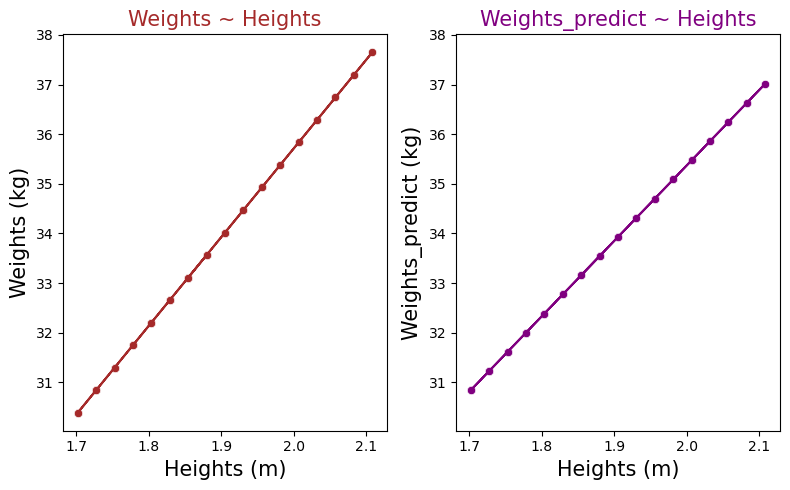

In [233]:
print('\n=============================================================')
print('*** 7) Visualize weights (y) and weights_predict (y_hypo) along with heights (x)***')
print('=============================================================')

#weights_predict = np.asarray(weights_predict, dtype=float) #convert the weights_predict dtype from '0' to float to visualize it

fig = plt.figure(figsize=(8,5))
grsp = GridSpec(nrows=1, ncols=2)

weights_fig = fig.add_subplot(grsp[0,0])
sbn.scatterplot(x=heights, y=weights, color='brown') #draw scatter plot
plt.plot(heights, weights, color='brown')            #draw line
weights_fig.set_xlabel('Heights (m)', size=15)
weights_fig.set_ylabel('Weights (kg)', size=15)
weights_fig.set_title('Weights ~ Heights',size=15,color='brown')

weights_predict_fig = fig.add_subplot(grsp[0,1], sharey = weights_fig) #sharey=weights_fig to use the same y axis scale like weights_fig
sbn.scatterplot(x=heights, y=weights_predict, color='purple')
plt.plot(heights, weights_predict, color='purple')
weights_predict_fig.set_xlabel('Heights (m)', size=15)
weights_predict_fig.set_ylabel('Weights_predict (kg)', size=15)
weights_predict_fig.set_title('Weights_predict ~ Heights',size=15,color='purple')

plt.tight_layout()

plt.show()

In [239]:
print('\n=============================================================')
print('*** 7) Given heights are 1.8, 1.9, 2.0. What are the weights_predict? ***')
print('=============================================================')

for height in [1.8, 1.9, 2.0]:
    print(f'\nIf height is {height} (m) then weight_predict = {slope}*{height} + {bias} = {slope*height + bias} kg')


*** 7) Given heights are 1.8, 1.9, 2.0. What are the weights_predict? ***

If height is 1.8 (m) then weight_predict = 15.189237916826759*1.8 + 4.995079578090801 = 32.335707828378965 kg

If height is 1.9 (m) then weight_predict = 15.189237916826759*1.9 + 4.995079578090801 = 33.85463162006164 kg

If height is 2.0 (m) then weight_predict = 15.189237916826759*2.0 + 4.995079578090801 = 35.37355541174432 kg
